Контекст
Вы работаете в отделе безопасности крупного банка. Перед вами стоит критически важная задача: разработать систему обнаружения мошеннических операций по кредитным картам в реальном времени. Для этого вам предоставили анонимизированный датасет транзакций.

Датасет: [Credit Card Fraud Detection]( https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Постановка задачи
Проведите сравнительный анализ алгоритмов машинного обучения для задачи бинарной классификации транзакций на:

Легальные (Class = 0)

Мошеннические (Class = 1)

In [2]:
## Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, Ridge, LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import statsmodels
from sklearn.preprocessing import StandardScaler

Задача 1. Предобработка данных (1 балл)

- Изучите распределение целевой переменной (анализ дисбаланса классов). Постройте графики

- Проведите масштабирование признаков (V1-V28 уже нормализованы, но Time и Amount требуют обработки)

- Разделите данные на обучающую и тестовую выборки (учтите стратификацию из-за дисбаланса)

In [3]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<Axes: xlabel='Time', ylabel='Count'>

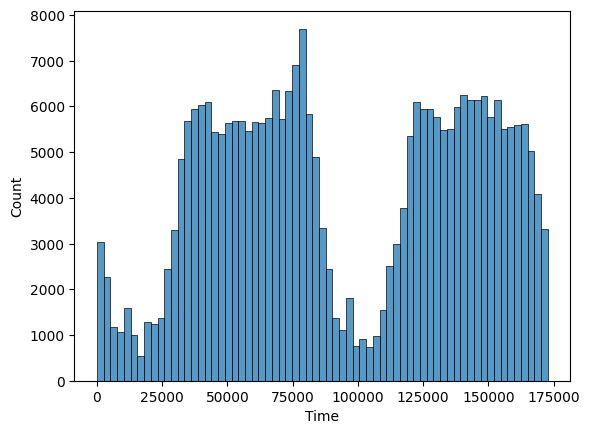

In [4]:
sns.histplot(df['Time'], bins =  'auto')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [34]:
X = df.drop(['Class'], axis = 1)
#таргет
y = df['Class']

In [35]:
Time_scale = X['Time'].std()
Time_mu = X['Time'].mean()

Amount_scale = X['Amount'].std()
Amount_mu = X['Amount'].mean()

In [33]:
# стандартизация time и amount
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])
X[['Time', 'Amount']].head()


1.000001755579451


,Time,Amount
0,-1.996583,0.244964
1,-1.996583,-0.342475
2,-1.996562,1.160686
3,-1.996562,0.140534
4,-1.996541,-0.073403


In [9]:
# # sns.histplot(X['V1'], bins =  'auto')
# n = 'V8'
# print(X[n].mean())
# print(X[n].std())
# sns.boxplot(X[n])

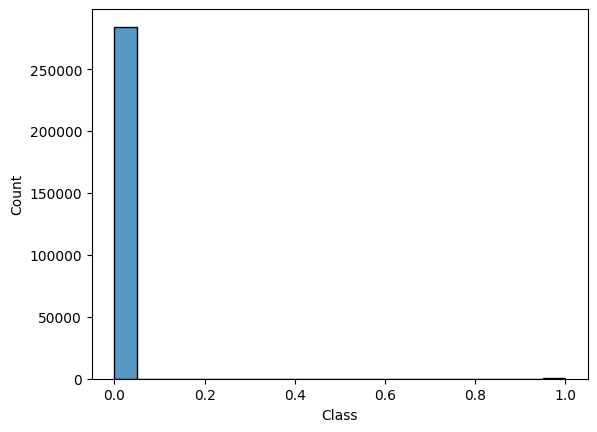

Class
0    284315
1       492
Name: count, dtype: int64
Доля класса "0" равна: 0.9982725143693799


In [10]:
#распределение класов
sns.histplot(y, bins = 'auto')
plt.show()
class_counts = df['Class'].value_counts()
print(class_counts)

print(f'Доля класса "0" равна: {(class_counts[0]) / len(y)}')


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, test_size=0.2, random_state=42, stratify=y)

X2_test = X_test.copy()

Задача 2. Построение   моделей ( 2 балла)

Реализуйте следующие алгоритмы:

Базовые модели:

- Линейная регрессия (с пороговой функцией)

- kNN (k-ближайших соседей)

- Решающее дерево

Ансамблевые методы:

- Бэггинг (BaggingClassifier)

- Случайный лес (Random Forest)

- Стекинг (StackingClassifier) для моделей

  *   LogisticRegression,
  *  KNeighborsClassifier,
  *  DecisionTreeClassifier


Может долго работать, но примерно до 15-20 минут !

In [12]:
# логистическая регрессия
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression(random_state=1)
model_LR.fit(X_train, y_train)

y_pred_LR = model_LR.predict(X_test)

In [13]:
# kNN
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5) 
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

In [14]:
# решающее дерево
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42)
model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)

In [15]:
# бэггинг
from sklearn.ensemble import BaggingClassifier

model_bagging = BaggingClassifier(n_estimators=20, random_state=42)
model_bagging.fit(X_train, y_train)

y_pred_bagging = model_bagging.predict(X_test)



In [16]:
# случайны лес 
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)


In [17]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('lr', LogisticRegression(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

model_stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
model_stacking.fit(X_train, y_train)

y_pred_stacking = model_stacking.predict(X_test)

Задача 3. Оценка моделей ( 2 балла )

Для каждой модели рассчитайте:

- Precision и Recall

- F1-score (основная метрика из-за дисбаланса)

- ROC-AUC

- Матрицу ошибок (Confusion Matrix)

Подсказка: Мы оцениваем на тестовой выборке

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


data = [
    ("LogReg",       model_LR,       y_pred_LR),
    ("kNN",          model_knn,      y_pred_knn),
    ("Tree",         model_tree,     y_pred_tree),
    ("Bagging",      model_bagging,  y_pred_bagging),
    ("RandomForest", model_rf,       y_pred_rf),
    ("Stacking",     model_stacking, y_pred_stacking)
]

print(f"{'Model':<15} F1      ROC     Prec    Recall")
print("-" * 45)

for name, model, pred in data:
    f1 = f1_score(y_test, pred)
    p = precision_score(y_test, pred)
    r = recall_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)
    
    prob = model.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, prob)
    
    print(f"{name:<15} {f1:.3f}   {roc:.3f}   {p:.3f}   {r:.3f}")
    print(f"Matrix: {cm.tolist()}\n")


Model           F1      ROC     Prec    Recall
---------------------------------------------
LogReg          0.724   0.957   0.829   0.643
Matrix: [[56851, 13], [35, 63]]

kNN             0.859   0.944   0.919   0.806
Matrix: [[56857, 7], [19, 79]]

Tree            0.808   0.918   0.781   0.837
Matrix: [[56841, 23], [16, 82]]

Bagging         0.880   0.938   0.942   0.827
Matrix: [[56859, 5], [17, 81]]

RandomForest    0.874   0.974   0.941   0.816
Matrix: [[56859, 5], [18, 80]]

Stacking        0.838   0.961   0.926   0.765
Matrix: [[56858, 6], [23, 75]]



Выводы:

Задача 4. Сравнительный анализ ( 1 балл)

Создайте сводную таблицу со всеми метриками и проведите анализ:

- Какая модель показывает наилучшее качество?

- Какие модели лучше обнаруживают мошеннические транзакции (высокий recall)?

- Какие модели минимизируют ложные срабатывания (высокий precision)?

In [19]:
data = {
    'Model': ['LogReg', 'kNN', 'Tree', 'Bagging', 'RandomForest', 'Stacking'],
    'F1-score': [0.724, 0.859, 0.808, 0.880, 0.874, 0.838],
    'ROC-AUC': [0.957, 0.944, 0.918, 0.938, 0.974, 0.961],
    'Precision': [0.829, 0.919, 0.781, 0.942, 0.941, 0.926],
    'Recall': [0.643, 0.806, 0.837, 0.827, 0.816, 0.765]
}

df_results = pd.DataFrame(data)
print(df_results.sort_values(by='F1-score', ascending=False))

          Model  F1-score  ROC-AUC  Precision  Recall
3       Bagging     0.880    0.938      0.942   0.827
4  RandomForest     0.874    0.974      0.941   0.816
1           kNN     0.859    0.944      0.919   0.806
5      Stacking     0.838    0.961      0.926   0.765
2          Tree     0.808    0.918      0.781   0.837
0        LogReg     0.724    0.957      0.829   0.643


Ответы: 
1) Наилучшее качество показала модель Bagging, тк у нее самое большое значение основной метрики f1-score. (Случайный лес тоже очень точно классифицировал данные)
2) Решающее дерево лучше всего справилось с обнаружением мошенников, recall = 0.837, но скорее всего из-за этого просела метрика точности precision = 0.781
3) Bagging лучше всего минимизировал ложные срабатывания, precision = 0.942

Задача 5. Углубленный анализ ошибок ( 2 балла)
- Проанализируйте ложно-положительные и ложно-отрицательные случаи лучшей модели

- Определите паттерны в транзакциях, которые модель классифицирует неправильно

- Визуализируйте распределение ошибок по признакам Amount и Time

In [36]:
X2_test['Class_true'] = y_test
X2_test['Class_pred'] = y_pred_bagging

X2_test['Amount'] = X2_test['Amount'] * Amount_scale + Amount_mu
X2_test['Time'] = X2_test['Time'] * Time_scale + Time_mu

# Ложно-плоожительные 
fp_mask = (X2_test['Class_pred'] == 1) & (X2_test['Class_true'] == 0)
# Ложно-отрицательные
fn_mask = (X2_test['Class_pred'] == 0) & (X2_test['Class_true'] == 1)

err_fp = X2_test[fp_mask]
err_fn = X2_test[fn_mask]


print(f"Количество ложных срабатываний: {len(err_fp)}")
print(f"Количество пропущенных мошенников: {len(err_fn)}")

Количество ложных срабатываний: 5
Количество пропущенных мошенников: 17


In [38]:
# Среднее значение 
print(f"Средний чек во всем датасете (все): {X2_test['Amount'].mean():.2f} ")
print(f"Средняя сумма, когда мы зря заблокировали клиента (FP): {err_fp['Amount'].mean():.2f}")
print(f"Средняя сумма, которую украли, а мы не заметили (FN):   {err_fn['Amount'].mean():.2f}")

# Медиана 
print(f"Медианный чек во всем датасете: {X2_test['Amount'].median():.2f}")
print(f"Медиана ошибочной блокировки (FP): {err_fp['Amount'].median():.2f} ")
print(f"Медиана пропущенной кражи (FN):    {err_fn['Amount'].median():.2f}")

Средний чек во всем датасете (все): 89.04 
Средняя сумма, когда мы зря заблокировали клиента (FP): 8.51
Средняя сумма, которую украли, а мы не заметили (FN):   129.95
Медианный чек во всем датасете: 22.00
Медиана ошибочной блокировки (FP): 1.00 
Медиана пропущенной кражи (FN):    5.91


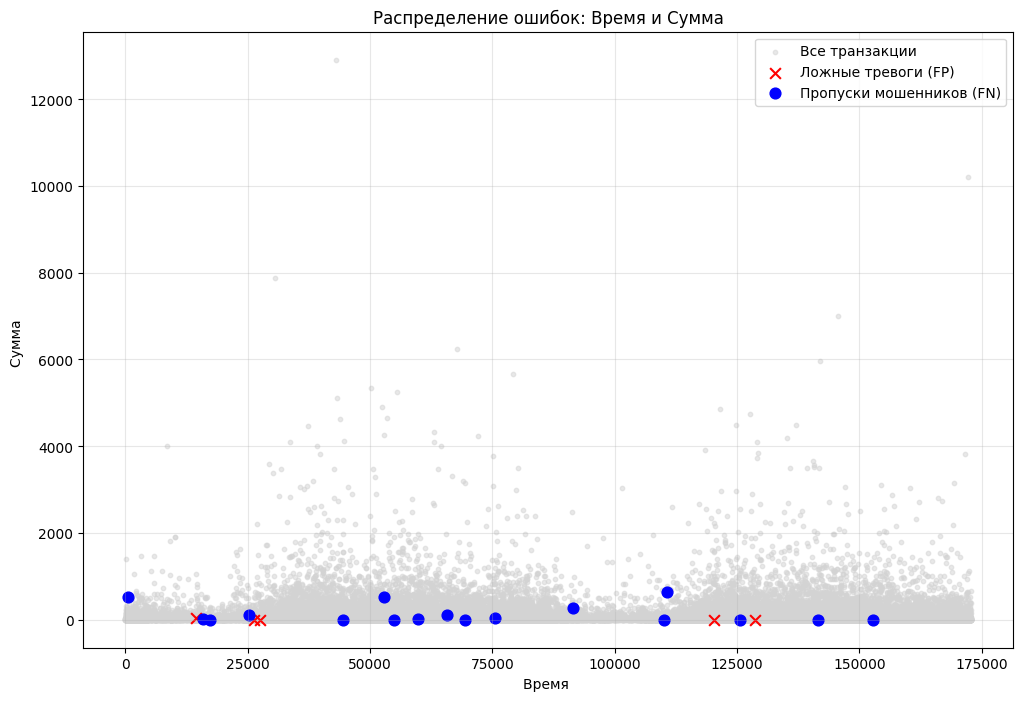

In [41]:

plt.figure(figsize=(12, 8))

# все точки серым 
plt.scatter(X2_test['Time'], X2_test['Amount'], c='lightgrey', label='Все транзакции', alpha=0.5, s=10)

#  Ложные тревоги (красным)
plt.scatter(err_fp['Time'], err_fp['Amount'], c='red', label='Ложные тревоги (FP)', marker='x', s=60)

# Пропуски мошенников (синие)
plt.scatter(err_fn['Time'], err_fn['Amount'], c='blue', label='Пропуски мошенников (FN)', marker='o', s=60)

plt.title('Распределение ошибок: Время и Сумма')
plt.xlabel('Время ')
plt.ylabel('Сумма ')
plt.legend()
plt.grid(True, alpha=0.3) 


Выводы:
1) FP - модель очень редко ошибается на честных людях и если ошибается, то на мелких транзакцих
2) FN - модель тоже редко ошибается, большинство пропушенных мошенничеств это также мелкие транзакции

Задача 6. Подбор гиперпараметров (2 балла)

- Подберите оптимальные гиперпараметры с помощью [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) для лучшей модели.
-  Построй модель с лучшими параметрами и оцени
- Напиши выводы о лучшей модели.

##### Хоть в моем случае лучшая модель это Bagging, подбирать оптимальные параметры буду для случайного леса, тк качество модели почти не отличается, а параметров у случайного леса больше и интересноп проверить именного его

In [42]:
from sklearn.model_selection import GridSearchCV


params = {
    'n_estimators': [50, 100],        
    'max_depth': [10, 15, 20],        # Максимальная глубина дерева (контроль переобучения)
    'min_samples_leaf': [1, 3, 5]     # Минимальное кол-во объектов в листе (сглаживание)
}

# cv=3 — кросс-валидация на 3 части 
# scoring='f1' — ищем параметры, которые дадут лучший F1-score

grid = GridSearchCV(model_rf, params, cv=3, scoring='f1', n_jobs=-1)

grid.fit(X_train, y_train) 

print("Лучшие параметры:", grid.best_params_)
print("Лучший F1 на кросс-валидации:", grid.best_score_)

Лучшие параметры: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 100}
Лучший F1 на кросс-валидации: 0.8446963239902798


Выводы: лучшая модель получилась для параметров: 
1) максимальная глубина дерева = 15
2) минимальный размер листа = 1
3) количество деревьев = 100
